# BTC Price Forecasting — Prophet Model


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
np.float_ = np.float64
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

plt.rcParams.update({
    'figure.facecolor': '#0a0a0f',
    'axes.facecolor':   '#12121f',
    'axes.edgecolor':   '#f7931a44',
    'axes.labelcolor':  '#e8e8f0',
    'xtick.color':      '#e8e8f0',
    'ytick.color':      '#e8e8f0',
    'text.color':       '#e8e8f0',
    'grid.color':       '#1e1e2e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

## 1 · Load & Parse Data

In [ ]:
CSV_PATH = '/content/bitcoin_price_2015_2025.csv'
raw_df = pd.read_csv(CSV_PATH)
raw_df.columns = [c.strip() for c in raw_df.columns]
print('Columns:', raw_df.columns.tolist())
raw_df.head()

Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


,Date,Close,High,Low,Open,Volume
0,NaN,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,2015-01-01,314.2489929199219,320.43499755859375,314.00299072265625,320.43499755859375,8036550
2,2015-01-02,315.0320129394531,315.8389892578125,313.56500244140625,314.0790100097656,7860650
3,2015-01-03,281.0820007324219,315.1499938964844,281.0820007324219,314.84600830078125,33054400
4,2015-01-04,264.19500732421875,287.2300109863281,257.61199951171875,281.14599609375,55629100


In [ ]:
date_candidates = [
    c for c in raw_df.columns
    if any(k in c.lower() for k in ['date', 'time', 'timestamp'])
]
price_candidates = [
    c for c in raw_df.columns
    if any(k in c.lower() for k in ['close', 'open', 'high', 'low', 'price'])
]

if not date_candidates or not price_candidates:
    raise ValueError("Could not detect date or price columns")

date_col  = next((c for c in date_candidates if 'date' in c.lower()), date_candidates[0])
price_col = next((c for c in price_candidates if 'close' in c.lower()), price_candidates[0])

print(f"Date column  : {date_col}")
print(f"Price column : {price_col}")

df = raw_df[[date_col, price_col]].copy()
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

if df[price_col].dtype == object:
    df[price_col] = (
        df[price_col].astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('$', '', regex=False)
        .str.strip()
    )
df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
df = df.dropna().sort_values(date_col).reset_index(drop=True)

price_series = df.rename(columns={date_col: 'ds', price_col: 'y'})[['ds', 'y']]
price_series['ds'] = pd.to_datetime(price_series['ds'])
price_series = price_series.drop_duplicates(subset='ds').dropna()
price_series = price_series.sort_values('ds').reset_index(drop=True)

if len(price_series) < 20:
    raise ValueError("Too few rows for Prophet (need at least ~20)")
if price_series['y'].nunique() == 1:
    raise ValueError("Price is constant — Prophet will fail")

# Resample to daily to fill any gaps
price_series = price_series.set_index('ds').resample('D').mean().reset_index()
price_series['y'] = price_series['y'].interpolate()

print(price_series.head())
print("\nMissing values:\n", price_series.isna().sum())
print(f"\nRows: {len(price_series):,}")
print(f"Date range: {price_series['ds'].min().date()} → {price_series['ds'].max().date()}")
print("\nFinal shape:", price_series.shape)

Date column  : Date
Price column : Close
          ds           y
0 2015-01-01  314.248993
1 2015-01-02  315.032013
2 2015-01-03  281.082001
3 2015-01-04  264.195007
4 2015-01-05  274.473999

Missing values:
 ds    0
y     0
dtype: int64

Rows: 3,912
Date range: 2015-01-01 → 2025-09-16

Final shape: (3912, 2)


## 2 · Exploratory Analysis

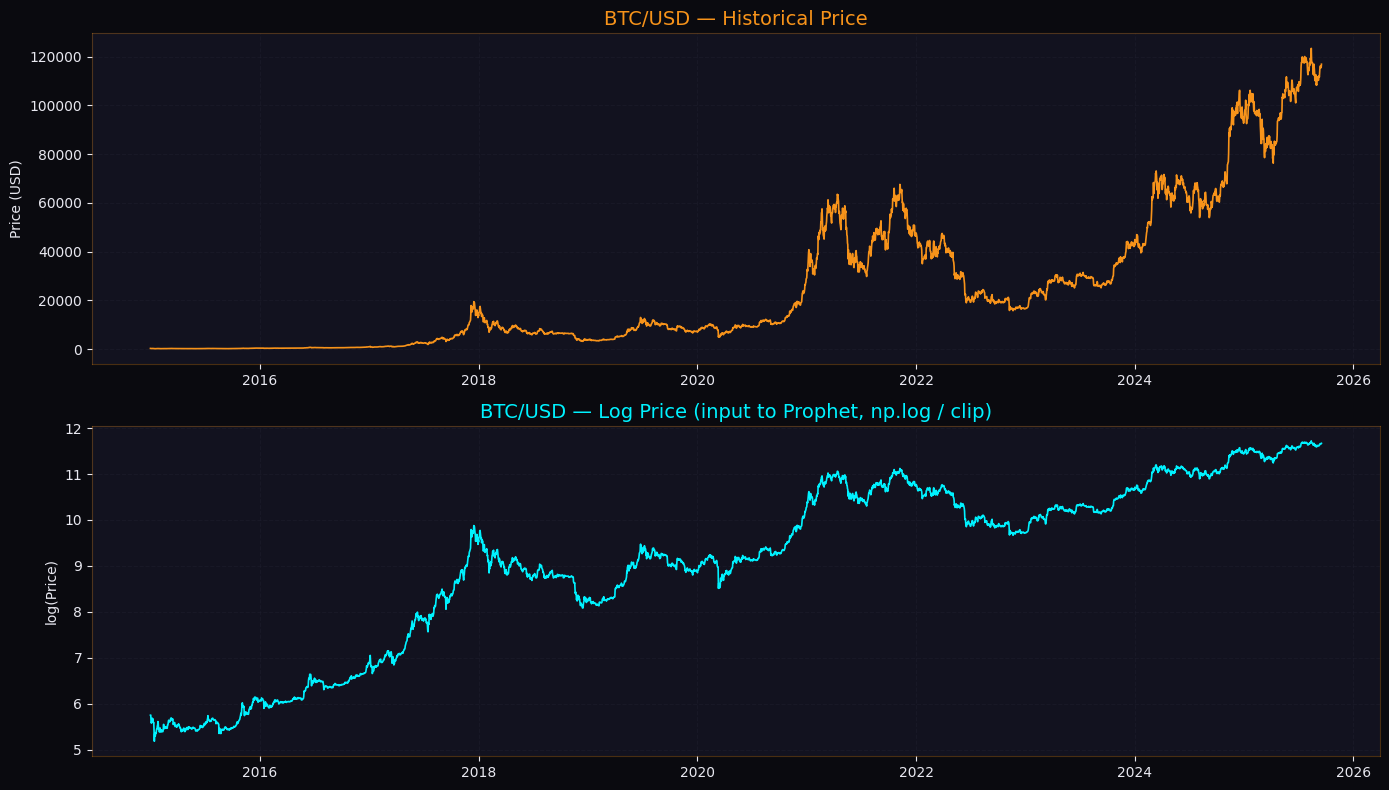

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(price_series.ds, price_series.y, color='#f7931a', linewidth=1.2)
axes[0].set_title('BTC/USD — Historical Price', fontsize=14, color='#f7931a')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True)

axes[1].plot(price_series.ds, np.log(price_series.y.clip(lower=1e-9)),
             color='#00f2ff', linewidth=1.2)
axes[1].set_title('BTC/USD — Log Price (input to Prophet, np.log / clip)', fontsize=14, color='#00f2ff')
axes[1].set_ylabel('log(Price)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3 · Train / Test Split



In [ ]:
TEST_RATIO = 0.10

price_series['ds'] = pd.to_datetime(price_series['ds'], errors='coerce')
price_series['y']  = pd.to_numeric(price_series['y'], errors='coerce')
price_series = price_series.dropna().sort_values('ds').drop_duplicates('ds')

split= int(len(price_series) * (1 - TEST_RATIO))
train_df = price_series.iloc[:split].copy()
test_df= price_series.iloc[split:].copy()
train_log = train_df.copy()
train_log['y'] = np.log(train_log['y'].clip(lower=1e-9))

assert train_log['y'].isna().sum() == 0
print(f"Train : {len(train_df):,} rows ({train_df.ds.min().date()} → {train_df.ds.max().date()})")
print(f"Test  : {len(test_df):,} rows  ({test_df.ds.min().date()} → {test_df.ds.max().date()})")
print("train_log uses np.log(clip) — inverse is np.exp")
print("test_df keeps original USD prices — comparisons are in USD")

Train : 3,520 rows (2015-01-01 → 2024-08-20)
Test  : 392 rows  (2024-08-21 → 2025-09-16)

train_log uses np.log(clip) — inverse is np.exp
test_df keeps original USD prices — comparisons are in USD


## 4 · Baseline Model (Additive, No Monthly Seasonality)

In [ ]:
baseline_model = Prophet(
    interval_width=0.95,
    seasonality_mode='additive',
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_prior_scale=5.0,
)
baseline_model.fit(train_log)
print('Baseline model fitted ✓')

Baseline model fitted ✓


## 5 · Best Model — Multiplicative + Monthly Seasonality


In [ ]:
second_model = Prophet(
    interval_width=0.95,
    seasonality_mode='multiplicative',
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False,
    mcmc_samples=0,
)
second_model.add_seasonality(
    name='monthly_seasonality',
    period=30,
    fourier_order=10,
    mode='additive',
)
second_model.fit(train_log)
print('Best model fitted ✓')

Best model fitted ✓


## 6 · Backtest Both Models

In [ ]:
def backtest_prophet(model, test_df):
    future   = model.make_future_dataframe(periods=len(test_df))
    forecast = model.predict(future)
    forecast['yhat']= np.exp(forecast['yhat'])
    forecast['yhat_lower'] = np.exp(forecast['yhat_lower'])
    forecast['yhat_upper'] = np.exp(forecast['yhat_upper'])

    pred = forecast['yhat'].values[-len(test_df):]

    mae  = np.mean(np.abs(test_df['y'].values - pred))
    rmse = np.sqrt(np.mean((test_df['y'].values - pred) ** 2))
    mape = np.mean(np.abs((test_df['y'].values - pred) / test_df['y'].values)) * 100
    return forecast, pred, mae, rmse, mape

fc_base, pred_base, mae_base, rmse_base, mape_base = backtest_prophet(baseline_model, test_df)
fc_2nd,  pred_2nd,  mae_2nd,  rmse_2nd,  mape_2nd  = backtest_prophet(second_model,   test_df)

print('Model Comparison (Backtest) — all errors in USD')
print(f'{"": <22} {"MAE":>12} {"RMSE":>12} {"MAPE":>8}')
print('-' * 58)
print(f'{"Baseline (additive)":<22} ${mae_base:>10,.2f} ${rmse_base:>10,.2f} {mape_base:>7.2f}%')
print(f'{"Best (multiplicative)":<22} ${mae_2nd:>10,.2f}  ${rmse_2nd:>10,.2f} {mape_2nd:>7.2f}%')

Model Comparison (Backtest) — all errors in USD
                                MAE         RMSE     MAPE
----------------------------------------------------------
Baseline (additive)    $ 14,121.06 $ 16,610.80   14.95%
Best (multiplicative)  $ 14,003.62  $ 16,872.36   14.86%


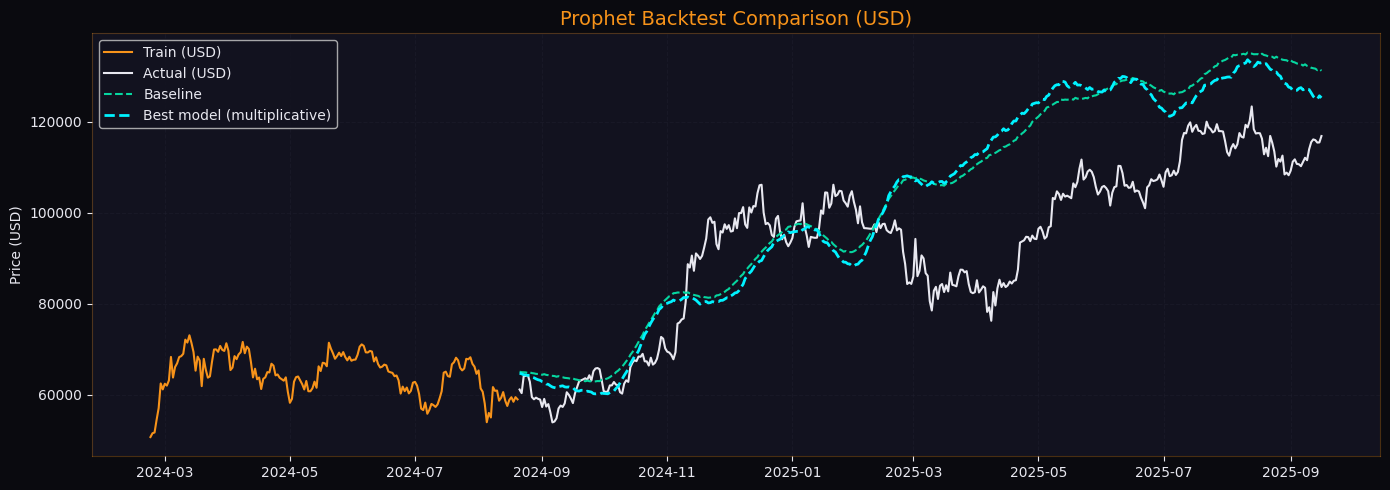

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_df.ds.iloc[-180:], train_df.y.iloc[-180:],
        color='#f7931a', linewidth=1.5, label='Train (USD)')
ax.plot(test_df.ds, test_df.y,
        color='#e8e8f0', linewidth=1.5, label='Actual (USD)')
ax.plot(test_df.ds, pred_base,
        color='#06d6a0', linewidth=1.5, linestyle='--', label='Baseline')
ax.plot(test_df.ds, pred_2nd,
        color='#00f2ff', linewidth=2, linestyle='--', label='Best model (multiplicative)')

ax.set_title('Prophet Backtest Comparison (USD)', fontsize=14, color='#f7931a')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 7 · Cross-Validation (Best Model)



In [ ]:
full_log = price_series.copy()
full_log['y'] = np.log(full_log['y'].clip(lower=1e-9))

cv_model = Prophet(
    interval_width=0.95,
    seasonality_mode='multiplicative',
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
)
cv_model.add_seasonality(
    name='monthly_seasonality', period=30, fourier_order=10, mode='additive'
)
cv_model.fit(full_log)

# Cross-validate: initial 2 years, horizon 60 days, step 30 days
df_cv = cross_validation(
    cv_model, initial='730 days', period='30 days', horizon='60 days',
    parallel='processes'
)
df_cv['yhat'] = np.exp(df_cv['yhat'])
df_cv['y']= np.exp(df_cv['y'])
df_perf = performance_metrics(df_cv)
print(df_perf[['horizon', 'mae', 'rmse', 'mape']].to_string(index=False))

INFO:prophet:Making 105 forecasts with cutoffs between 2017-01-01 00:00:00 and 2025-07-18 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7d6af6530320>


horizon          mae         rmse     mape
 6 days  8062.812373 13899.310441 0.247687
 7 days  8270.729162 14287.361366 0.255169
 8 days  8488.723552 14710.563209 0.263149
 9 days  8723.266318 15155.333336 0.271670
10 days  8947.036942 15574.704015 0.280206
11 days  9166.111745 15975.320189 0.288476
12 days  9348.249507 16298.301488 0.295624
13 days  9552.944158 16630.433680 0.304183
14 days  9706.878085 16876.755009 0.311077
15 days  9812.609073 17059.727604 0.317887
16 days  9919.549193 17288.547882 0.326090
17 days 10040.237334 17562.871293 0.332917
18 days 10192.542477 17874.075522 0.340614
19 days 10311.575391 18170.035276 0.346835
20 days 10458.343711 18473.461130 0.352961
21 days 10587.675365 18749.845430 0.357633
22 days 10729.481291 18992.006520 0.361588
23 days 10870.089405 19211.101713 0.366721
24 days 10935.810491 19346.669864 0.368678
25 days 11009.074406 19431.101989 0.370684
26 days 11074.324213 19491.058421 0.374204
27 days 11165.011304 19585.923971 0.378782
28 days 112

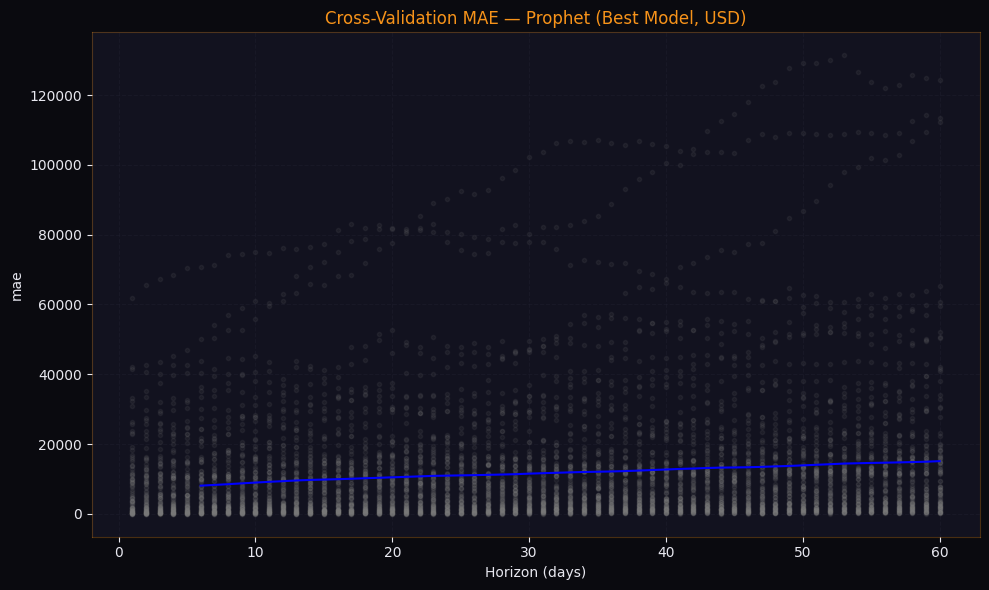

In [ ]:
fig = plot_cross_validation_metric(df_cv, metric='mae')
fig.set_facecolor('#0a0a0f')
plt.title('Cross-Validation MAE — Prophet (Best Model, USD)', color='#f7931a')
plt.tight_layout()
plt.show()

## 8 · Future Forecast (Best Model)



In [ ]:
HORIZON = 30
CI      = 0.95

full_model = Prophet(
    interval_width=CI,
    seasonality_mode='multiplicative',
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
)
full_model.add_seasonality(
    name='monthly_seasonality', period=30, fourier_order=10, mode='additive'
)
full_model.fit(full_log)

future   = full_model.make_future_dataframe(periods=HORIZON)
forecast = full_model.predict(future)

for col in ['yhat', 'yhat_lower', 'yhat_upper']:
    forecast[col] = np.exp(forecast[col])

future_fc = forecast.tail(HORIZON)
print(f'Forecast start : {future_fc.ds.iloc[0].date()}')
print(f'Forecast end   : {future_fc.ds.iloc[-1].date()}')
print(f'\nDay 1  forecast : ${future_fc.yhat.iloc[0]:,.2f}')
print(f'Day {HORIZON} forecast : ${future_fc.yhat.iloc[-1]:,.2f}')

Forecast start : 2025-09-17
Forecast end   : 2025-10-16

Day 1  forecast : $117,345.33
Day 30 forecast : $129,779.10


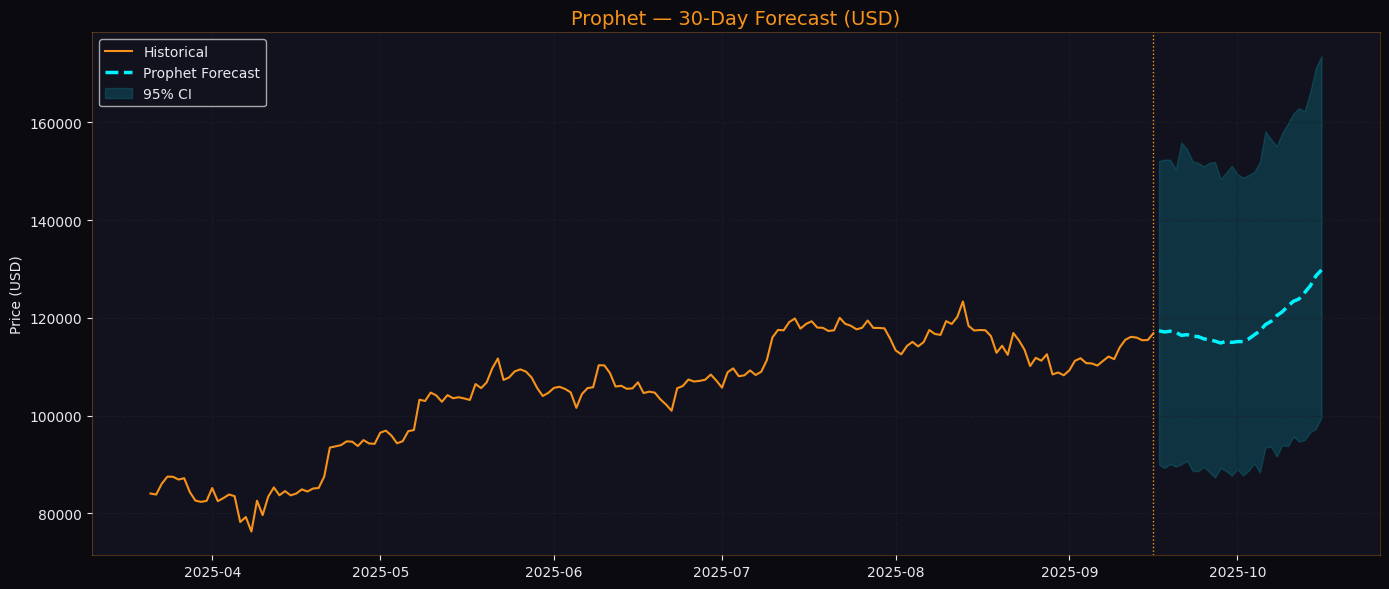

In [ ]:
hist = price_series.iloc[-180:]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(hist.ds, hist.y, color='#f7931a', linewidth=1.5, label='Historical')
ax.plot(future_fc.ds, future_fc.yhat,
        color='#00f2ff', linewidth=2.5, linestyle='--', label='Prophet Forecast')
ax.fill_between(future_fc.ds, future_fc.yhat_lower, future_fc.yhat_upper,
                alpha=0.15, color='#00f2ff', label=f'{int(CI*100)}% CI')
ax.axvline(price_series.ds.iloc[-1], color='#f7931a', linewidth=1, linestyle=':')
ax.set_title(f'Prophet — {HORIZON}-Day Forecast (USD)', fontsize=14, color='#f7931a')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 9 · Component Plot

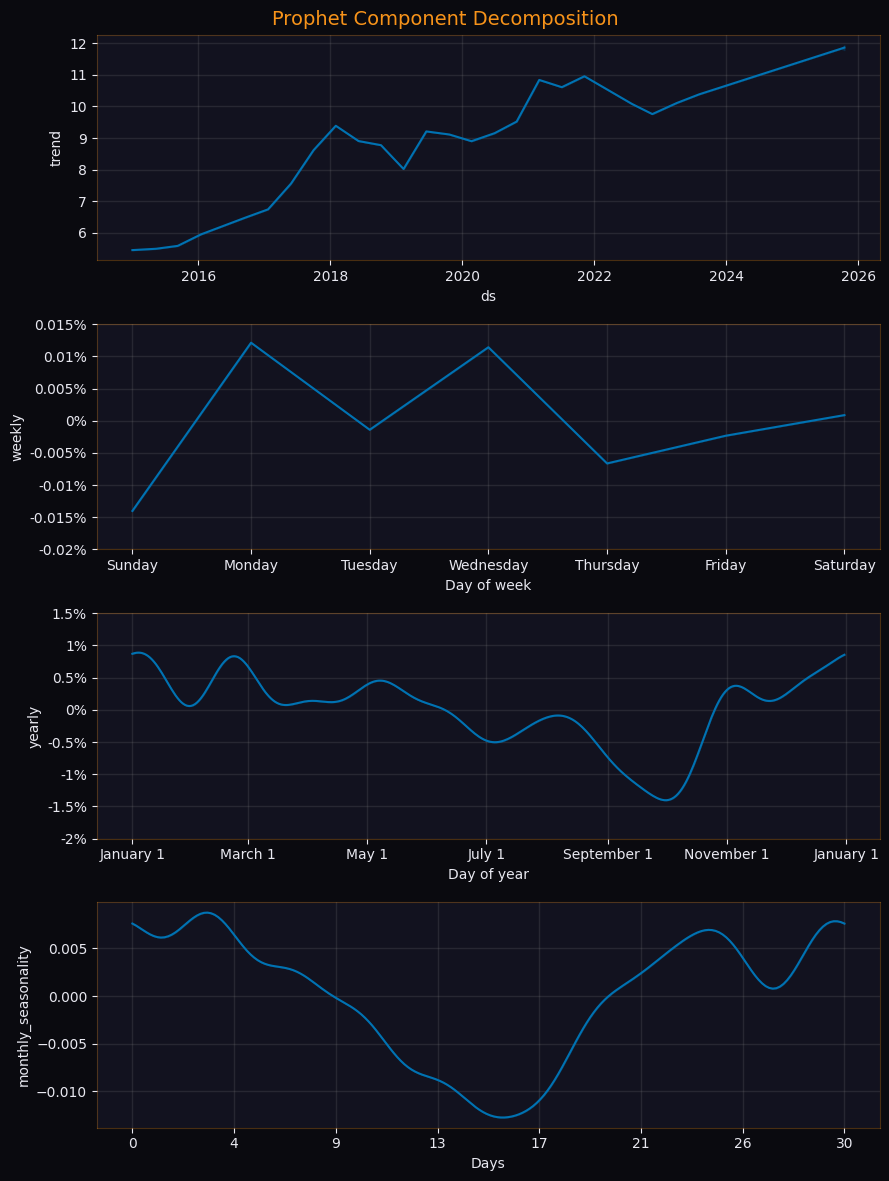

In [ ]:
fig = full_model.plot_components(forecast)
fig.set_facecolor('#0a0a0f')
for ax in fig.axes:
    ax.set_facecolor('#12121f')
    ax.tick_params(colors='#e8e8f0')
plt.suptitle('Prophet Component Decomposition', color='#f7931a', fontsize=14)
plt.tight_layout()
plt.show()

## 10 · Forecast Table

In [ ]:
fc_table = future_fc[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
fc_table.columns = [
    'Date', 'Forecast (USD)',
    f'Lower {int(CI*100)}% (USD)',
    f'Upper {int(CI*100)}% (USD)'
]
fc_table['Date'] = fc_table['Date'].dt.strftime('%Y-%m-%d')

fc_table.style.format({
    'Forecast (USD)':               '${:,.2f}',
    f'Lower {int(CI*100)}% (USD)':  '${:,.2f}',
    f'Upper {int(CI*100)}% (USD)':  '${:,.2f}',
})

,Date,Forecast (USD),Lower 95% (USD),Upper 95% (USD)
3912,2025-09-17,"$117,345.33","$89,933.26","$152,053.69"
3913,2025-09-18,"$117,091.19","$89,282.04","$152,399.48"
3914,2025-09-19,"$117,253.12","$90,070.67","$152,316.31"
3915,2025-09-20,"$117,043.31","$89,525.95","$150,404.54"
3916,2025-09-21,"$116,402.35","$90,019.85","$155,877.41"
3917,2025-09-22,"$116,547.81","$90,735.60","$154,486.19"
3918,2025-09-23,"$116,221.74","$88,658.60","$152,046.03"
3919,2025-09-24,"$116,150.64","$88,633.36","$151,699.54"
3920,2025-09-25,"$115,693.92","$89,499.06","$150,970.01"
3921,2025-09-26,"$115,517.69","$88,423.01","$151,740.85"
